# Assignment 2
### Understanding Uncertainty
### Due 9/12

1. 'State Bottle Retail' is the price at which the bottle is sold, while 'State Bottle Cost' is the price the state pays for a bottle.
- How do you define the most profitable item? Why? Explain your thinking.

- Use `.groupby` calculations to determine the most profitable liquors sold in Iowa.
- Make a plot of the top liquors.

In [7]:
import os
import pandas as pd
import numpy as np
wd = os.chdir("/Users/mta/Desktop/Understanding Uncertainty/MTA4KD/data")

In [8]:
iowa = pd.read_csv("iowa.csv", header=0)
print(iowa.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159904 entries, 0 to 159903
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Invoice/Item Number  159904 non-null  object 
 1   Date                 159904 non-null  object 
 2   Store Number         159904 non-null  int64  
 3   Store Name           159904 non-null  object 
 4   Zip Code             159508 non-null  object 
 5   Category Name        159771 non-null  object 
 6   Vendor Name          159904 non-null  object 
 7   Item Number          159904 non-null  int64  
 8   Item Description     159904 non-null  object 
 9   Bottle Volume (ml)   159904 non-null  int64  
 10  State Bottle Cost    159904 non-null  float64
 11  State Bottle Retail  159904 non-null  float64
 12  Bottles Sold         159904 non-null  int64  
 13  Sale (Dollars)       159904 non-null  float64
dtypes: float64(3), int64(4), object(7)
memory usage: 17.1+ MB
None


In [30]:
print(iowa.head(10))

print( "I would define the most profitable item as the one with the highest profit per fluid ounce, as this accounnts for both the price and the size of the item. This allows us to standardize and compare the profitability of different items regardless of their size.")

  Invoice/Item Number        Date  Store Number  \
0     INV-59108400026  06/06/2023          3723   
1        S16879800057  01/16/2014          3926   
2     INV-05301100019  06/05/2017          3829   
3     INV-40973500083  10/14/2021          5102   
4     INV-17022500013  01/18/2019          2560   
5        S32243000024  05/10/2016          5167   
6        S16316700048  12/18/2013          2536   
7     INV-84044800086  06/30/2025          2637   
8     INV-14344700002  09/10/2018          3611   
9        S08759700117  11/05/2012          2623   

                             Store Name Zip Code  \
0                    J D SPIRITS LIQUOR    51040   
1           LIQUOR DOWNTOWN / IOWA CITY    52240   
2              GARY'S FOODS / MT VERNON    52314   
3                        WILKIE LIQUORS    52314   
4            HY-VEE FOOD STORE / MARION    52302   
5  NEW STAR LIQUOR & TOBACCO  / FT DODG    50501   
6                HY-VEE / PLEASANT HILL    50317   
7                 HY-V

In [10]:
iowa['profit_per_bottle'] = iowa['State Bottle Retail'] - iowa['State Bottle Cost']
iowa['total_profit'] = iowa['Bottles Sold'] * iowa['profit_per_bottle']
iowa['total_ounces'] = iowa['Bottle Volume (ml)'] * 0.033814 * iowa['Bottles Sold']
iowa['profit_per_ounce'] = iowa['total_profit'] / iowa['total_ounces']

item_profit_oz = (
    iowa.groupby('Item Description', as_index=False)
        .agg({'total_profit':'sum','total_ounces':'sum'})
)
item_profit_oz['profit_per_ounce'] = item_profit_oz['total_profit'] / item_profit_oz['total_ounces']
item_profit_oz.sort_values('profit_per_ounce', ascending=False).head(10)

,Item Description,total_profit,total_ounces,profit_per_ounce
4026,REMY MARTIN LOUIS XIII,1149.42,25.3605,45.323239
1879,FIREBALL SQUARE PARTY BUCKET MINI,1290.00,33.8140,38.149879
4167,RUMCHATA PUMPKIN SPICE MINI,106.44,3.3814,31.478086
4163,RUMCHATA PEPPERMINT BARK MINI,212.88,6.7628,31.478086
4775,SUGARLANDS CANDY CANE VARIETY PACK,204.72,6.7628,30.271485
3295,MIDNIGHT MOON HOLIDAY CANDY CANE,48.00,1.6907,28.390607
5258,WHISTLEPIG 10YR MINI,143.83,5.0721,28.357091
1446,DARK CHOCOLATE COFFEE SIPPIN CREAM MINI,40.56,1.6907,23.990063
341,AVIATION AMERICAN GIN MINI,78.00,3.3814,23.067369
1590,DON JULIO 1942 MINI,487.50,21.9791,22.180162


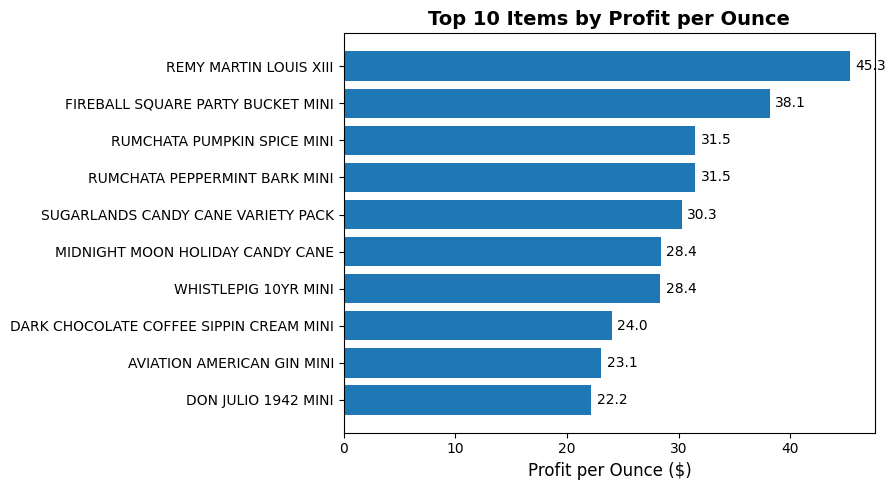

In [12]:
import matplotlib.pyplot as plt
top10profit = item_profit_oz.sort_values("profit_per_ounce", ascending=False).head(10)

plt.figure(figsize=(9,5))
bars = plt.barh(top10profit["Item Description"], top10profit["profit_per_ounce"], color="#1f77b4")
plt.xlabel("Profit per Ounce ($)", fontsize=12)
plt.title("Top 10 Items by Profit per Ounce", fontsize=14, weight="bold")
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.1f}",
        va="center", fontsize=10
    )

plt.tight_layout()
plt.show()


2. This question is to further explore broadcasting in NumPy.

- In the first code chunk below, there are two vectors, $x$ and $y$. What happens when you try to subtract them?
- Instead, try `x.reshape(-1,1)-y.reshape(-1,1)`. What do you get?
- Try `x.reshape(1,-1)-y.reshape(1,-1)`. Compare the results to your previous answer.
- Write two double for-loops to replicate the results of the previous two answers. 
- Clearly explain how `x.reshape(1,-1)` and `x.reshape(-1,1)` change $x$

In [17]:
import numpy as np

x = np.array([1,3,5])
y = np.array([2,5])

print("Attempting x - y directly:")
try:
    result = x - y
    print(result)
except ValueError as e:
    print("Error:", e)

Attempting x - y directly:
Error: operands could not be broadcast together with shapes (3,) (2,) 


In [21]:
a = np.array([[val] for val in x])  
b = np.array([[val] for val in y]) 

print("\nShapes for a and b:", a.shape, b.shape)
try:
    diff_ab = a - b
    print("a - b result:\n", diff_ab)
except ValueError as e:
    print("Error:", e)

c = np.array([val for val in x]).reshape(1, len(x))
d = np.array([val for val in y]).reshape(1, len(y))

print("\nShapes for c and d:", c.shape, d.shape)
try:
    diff_cd = c - d
    print("c - d result:\n", diff_cd)
except ValueError as e:
    print("Error:", e)


manual_ab = []
for i in range(len(a)):
    row = []
    for j in range(len(b)):
        row.append(a[i][0] - b[j][0])
    manual_ab.append(row)
manual_ab = np.array(manual_ab)
print("\nManual double loop result for a - b:\n", manual_ab)


manual_cd = []
for i in range(c.shape[1]): 
    row = []
    for j in range(d.shape[1]): 
        row.append(c[0][i] - d[0][j])
    manual_cd.append(row)
manual_cd = np.array(manual_cd)
print("\nManual double loop result for c - d:\n", manual_cd)

print("- x.reshape(-1,1) changes x into a column vector (shape (3,1)).")
print("- y.reshape(-1,1) also becomes a column vector (shape (2,1)).")
print("  Their shapes are incompatible for broadcasting across columns → mismatch.")
print("- x.reshape(1,-1) changes x into a row vector (shape (1,3)).")
print("- y.reshape(1,-1) changes y into a row vector (shape (1,2)).")
print("  Subtracting two row vectors tries to align columns, which also mismatches.")
print("- Using loops replicates what NumPy broadcasting would try, but slower.")


Shapes for a and b: (3, 1) (2, 1)
Error: operands could not be broadcast together with shapes (3,1) (2,1) 

Shapes for c and d: (1, 3) (1, 2)
Error: operands could not be broadcast together with shapes (1,3) (1,2) 

Manual double loop result for a - b:
 [[-1 -4]
 [ 1 -2]
 [ 3  0]]

Manual double loop result for c - d:
 [[-1 -4]
 [ 1 -2]
 [ 3  0]]
- x.reshape(-1,1) changes x into a column vector (shape (3,1)).
- y.reshape(-1,1) also becomes a column vector (shape (2,1)).
  Their shapes are incompatible for broadcasting across columns → mismatch.
- x.reshape(1,-1) changes x into a row vector (shape (1,3)).
- y.reshape(1,-1) changes y into a row vector (shape (1,2)).
  Subtracting two row vectors tries to align columns, which also mismatches.
- Using loops replicates what NumPy broadcasting would try, but slower.


3. The indicator function $\mathbb{I}\{ x \le z \}$ takes the value 0 if $x>z$ is false and 1 if $x \le z$ is true.

- For $y = 3$, plot the indicator function for any $z$
- Explain how $ 1- \mathbb{I}\{ x \le z \} = \mathbb{I}\{ x > z \}$. Drawing a plot might help, or looking at the definition that
$$
\mathbb{I}\{x \le z\} = \begin{cases}
0, &x > z \\
1, &x \le z
\end{cases}
$$
- The code below generates a random sample for different numbers of observations, $N = 3, 30, 300, 3000 $. Write a function to compute the ECDF curve for each sample, and plot your results.
- Describe in your own words what happens to the ECDF qualitatively as the sample size $N$ increases

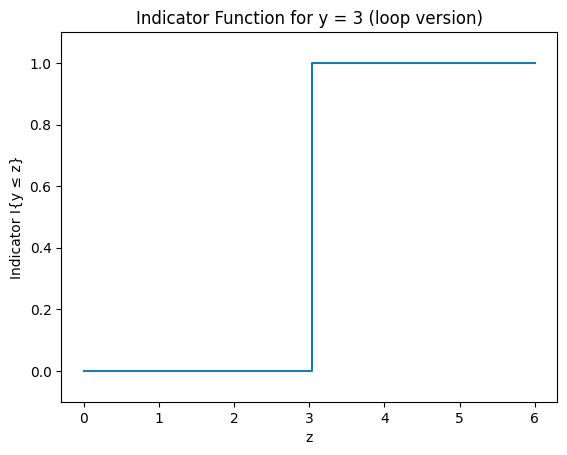

1 - I{x ≤ z} equals I{x > z} because when x ≤ z the first term is 0 and when x > z it is 1, matching the definition.


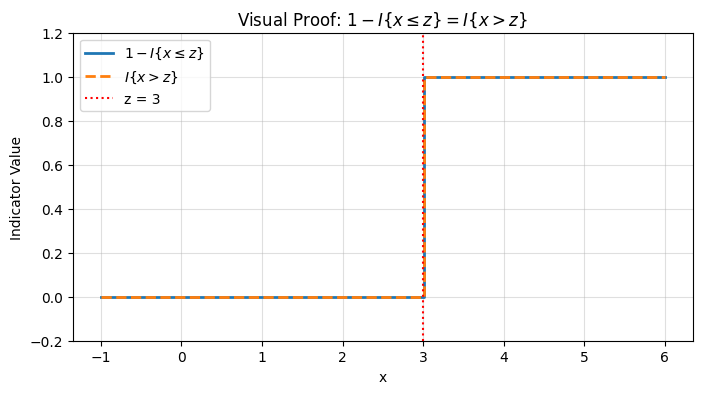

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def indicator(x, z):
    result = []
    for val in x:
        if val <= z:
            result.append(1)
        else:
            result.append(0)
    return result

z_values = np.linspace(0, 6, 100) 
y = 3

indicator_values = []
for z in z_values:
    indicator_values.append(indicator([y], z)[0]) 

plt.step(z_values, indicator_values, where="post")
plt.xlabel("z")
plt.ylabel("Indicator I{y ≤ z}")
plt.title("Indicator Function for y = 3 (loop version)")
plt.ylim(-0.1, 1.1)
plt.show()

print("1 - I{x ≤ z} equals I{x > z} because when x ≤ z the first term is 0 and when x > z it is 1, matching the definition.")

x_vals = np.linspace(-1, 6, 200)
z = 3  

I_leq = (x_vals <= z).astype(int)
lhs = 1 - I_leq
rhs = (x_vals > z).astype(int)

plt.figure(figsize=(8,4))
plt.step(x_vals, lhs, where="post", label=r"$1 - I\{x \leq z\}$", linewidth=2)
plt.step(x_vals, rhs, where="post", linestyle="--", label=r"$I\{x > z\}$", linewidth=2)
plt.axvline(z, color="red", linestyle=":", label=f"z = {z}")
plt.ylim(-0.2, 1.2)
plt.xlabel("x")
plt.ylabel("Indicator Value")
plt.title("Visual Proof: $1 - I\\{x \\leq z\\} = I\\{x > z\\}$")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

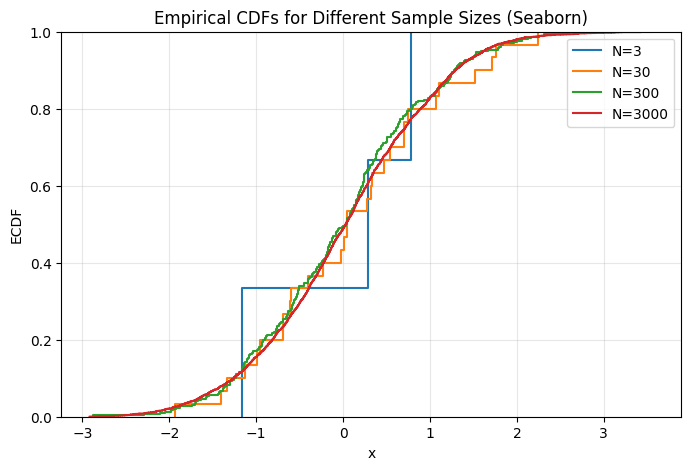

As N increases, the ECDF becomes smoother and approaches the true cumulative density function of the underlying distribution.


In [31]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

rng = np.random.default_rng(100)

plt.figure(figsize=(8,5))

for N in (3, 30, 300, 3000):
    X = rng.normal(0, 1, N)
    sns.ecdfplot(X, label=f"N={N}")

plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Empirical CDFs for Different Sample Sizes (Seaborn)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("As N increases, the ECDF becomes smoother and approaches the true cumulative density function of the underlying distribution.")

4. A **quantile** generalizes the concept of the median so that instead of 50% of the mass below and 50% above, the $q$-quantile is the value for which $q$ proportion of the data are below that value and $(1-q)$ proportion of the data are above that value. This is a concept of **order**.

- Write a function that computes any quantile without using Numpy's `np.quantile`
- Write a function that computes the **Interquartile Range (IQR)** -- the .25 quantile and the .75 quantile, which brackets 50% of the data -- and the **whiskers**: $\pm 1.5 \times \text{IQR}$ from the edges of the IQR
- Write a function that computes a five-number summary and values for a boxplot: the minimum, the .25 quantile, the median, the .75 quantile, and the maximum, and the whiskers
- Anything outside the whiskers is an **outlier**; write a function that returns a Boolean vector indicating if the observations are outliers.
- For a numeric variable of your choice from one of the datasets, apply your functions from above, and compare your answers with `sns.boxplot` and `df.describe`. 

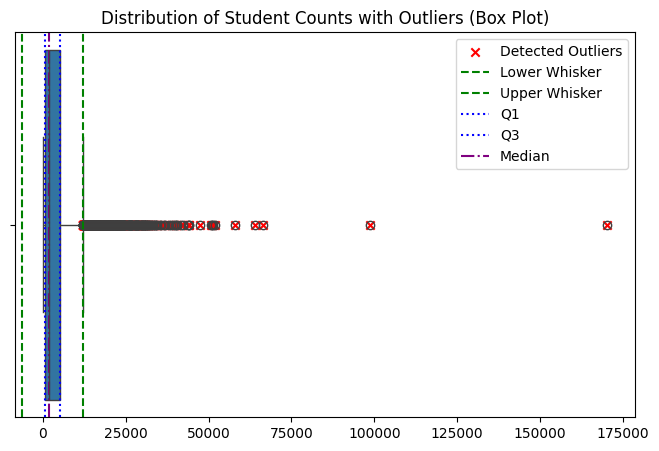

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("college_completion.csv")
x = df["student_count"].dropna().values

def my_quantile(data, q):
    data_sorted = np.sort(data)
    n = len(data_sorted)
    pos = q * (n - 1)
    lower = int(np.floor(pos))
    upper = int(np.ceil(pos))
    if lower == upper:
        return data_sorted[lower]
    else:
        return data_sorted[lower] + (pos - lower) * (data_sorted[upper] - data_sorted[lower])

def my_iqr(data):
    q1 = my_quantile(data, 0.25)
    q3 = my_quantile(data, 0.75)
    return q3 - q1, q1, q3

def five_number_summary(data):
    q1 = my_quantile(data, 0.25)
    median = my_quantile(data, 0.5)
    q3 = my_quantile(data, 0.75)
    return np.min(data), q1, median, q3, np.max(data)

def detect_outliers(data):
    iqr, q1, q3 = my_iqr(data)
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr
    return (data < lower_whisker) | (data > upper_whisker), lower_whisker, upper_whisker

outliers, lw, uw = detect_outliers(x)
iqr, q1, q3 = my_iqr(x)
summary = five_number_summary(x)

plt.figure(figsize=(8,5))
sns.boxplot(x=x)
plt.scatter(x[outliers], np.zeros(outliers.sum()), color="red", marker="x", label="Detected Outliers")
plt.axvline(lw, color="green", linestyle="--", label="Lower Whisker")
plt.axvline(uw, color="green", linestyle="--", label="Upper Whisker")
plt.axvline(q1, color="blue", linestyle=":", label="Q1")
plt.axvline(q3, color="blue", linestyle=":", label="Q3")
plt.axvline(summary[2], color="purple", linestyle="-.", label="Median")
plt.title("Distribution of Student Counts with Outliers (Box Plot)")
plt.legend()
plt.show()

5. The kernel density estimator captures the concentration of the data around various points, and is defined as
$$
\hat{f}_{N,h}(z) = \frac{1}{N} \sum_{i=1}^N \frac{1}{h} k \left( \frac{x_i - z}{h}\right)
$$
where $h$ is the bandwidth and $k()$ is one of the kernel functions from the class materials (Gaussian, Epanechnikov, uniform, triangular).

- Write a function that takes the bandwidth $h$ as given, and computes and plots $\hat{f}_{N,h}(z)$, for the kernels listed in the slides
- Write a function that computes the plug-in bandwidth
- Use your functions to analyze some numeric variables from a dataset of your choice, using a variety of bandwidths
- Compare bandwidths that are greater or less than the plug-in value with the results for the plug-in value. When does the KDE appear to be overfitting? Underfitting?